# SPIKE review

Display-only. Compute lives in `00_tb_dump.py`, `01_loss_matrix.py`, `02_gradnorm_matrix.py`, `03_adapter_svd.py`.

Cells silently skip if their artifacts don't exist yet.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path('out')
TB, LOSS, GRAD, SVD = OUT/'00_tb_dump', OUT/'01_loss_matrix', OUT/'02_gradnorm_matrix', OUT/'03_adapter_svd'

def skip(msg):
    print(f'skip: {msg}')

## §3 Adapter SVD

### §3.1 Singular value spectrum overlaid across stages (one layer × module)

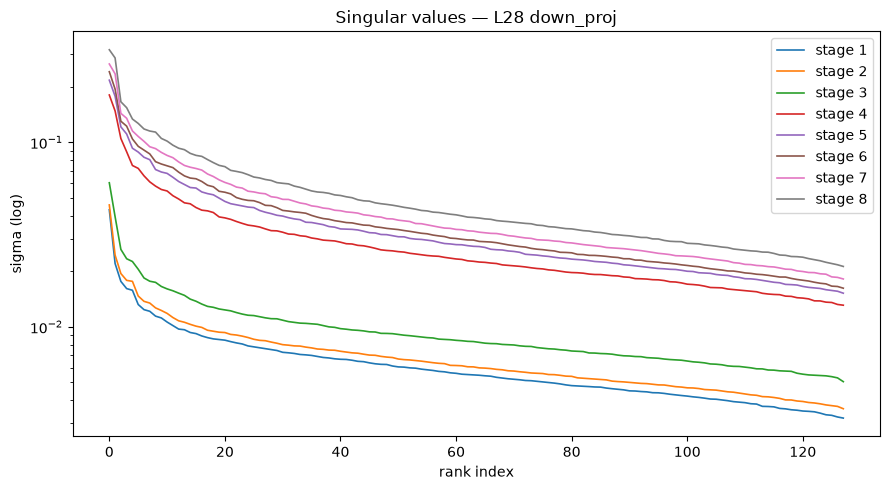

In [2]:
LAYER, MODULE = 28, 'down_proj'
if not (SVD/'scalars.parquet').exists():
    skip('run 03_adapter_svd.py first')
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    for npz_path in sorted(SVD.glob('stage_*_arrays.npz')):
        stage_idx = int(npz_path.stem.split('_')[1])
        z = np.load(npz_path)
        key = f'L{LAYER:02d}_{MODULE}__sigma'
        if key not in z.files:
            continue
        s = z[key]
        ax.semilogy(s, label=f'stage {stage_idx}', lw=1.2)
    ax.set(title=f'Singular values — L{LAYER} {MODULE}', xlabel='rank index', ylabel='sigma (log)')
    ax.legend()
    plt.tight_layout(); plt.show()

### §3.2 ‖ΔW‖_F heatmap (layer × module) per stage

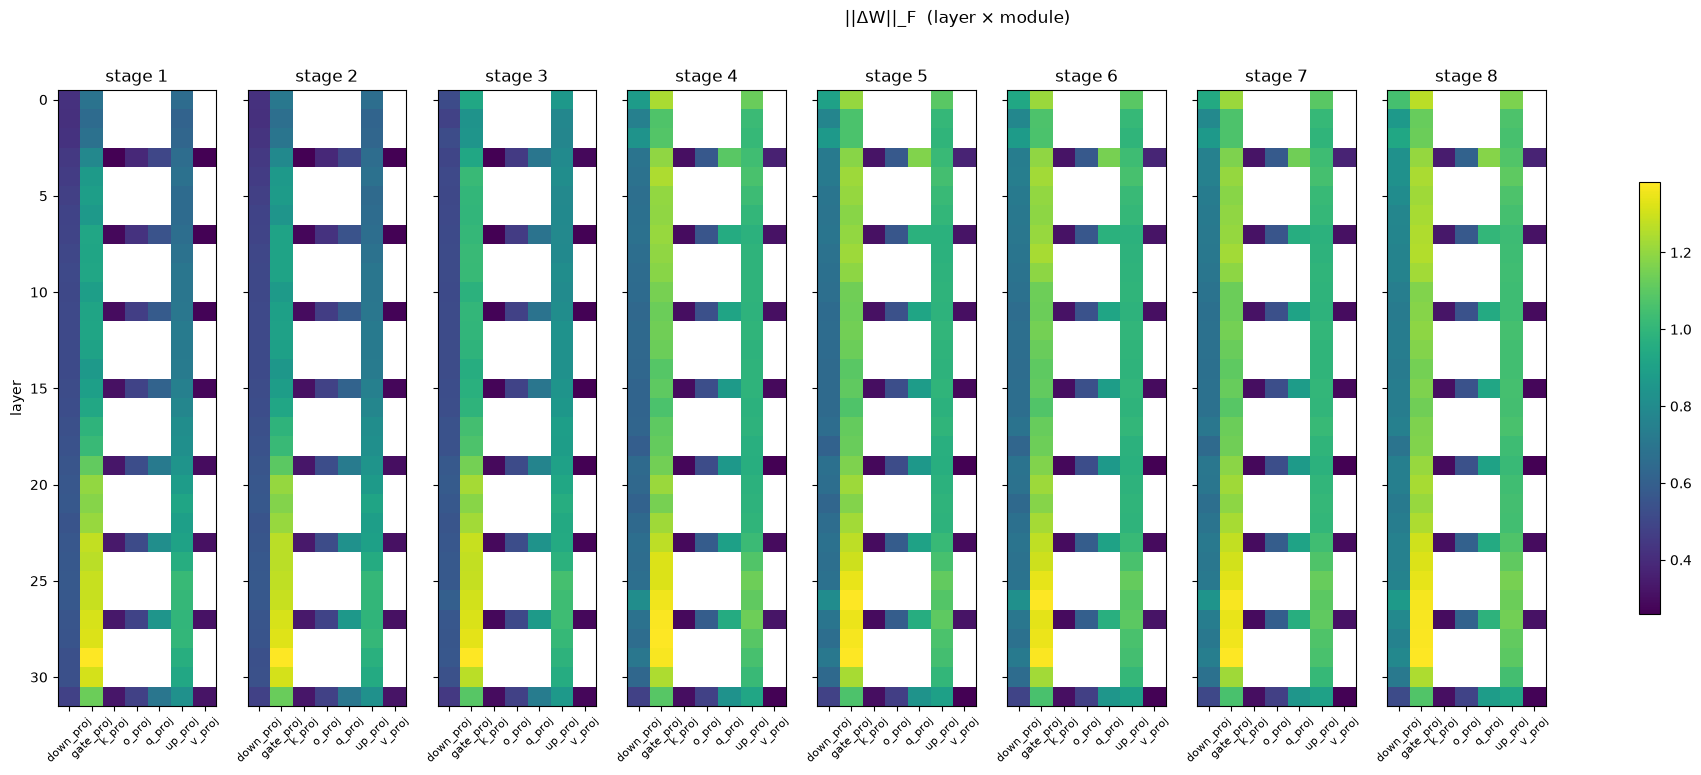

In [3]:
if not (SVD/'scalars.parquet').exists():
    skip('need scalars.parquet')
else:
    scalars = pd.read_parquet(SVD/'scalars.parquet')
    stages = sorted(scalars.stage_idx.unique())
    fig, axes = plt.subplots(1, len(stages), figsize=(3*len(stages), 8), sharey=True)
    for ax, sidx in zip(axes, stages):
        h = scalars[scalars.stage_idx == sidx].pivot(index='layer', columns='module', values='fro')
        im = ax.imshow(h.values, aspect='auto', cmap='viridis')
        ax.set_xticks(range(len(h.columns)))
        ax.set_xticklabels(h.columns, rotation=45, fontsize=8)
        ax.set_title(f'stage {sidx}')
    axes[0].set_ylabel('layer')
    fig.suptitle('||ΔW||_F  (layer × module)')
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7)
    plt.show()

### §3.2 Relative update size ‖ΔW‖_F  per module across stages

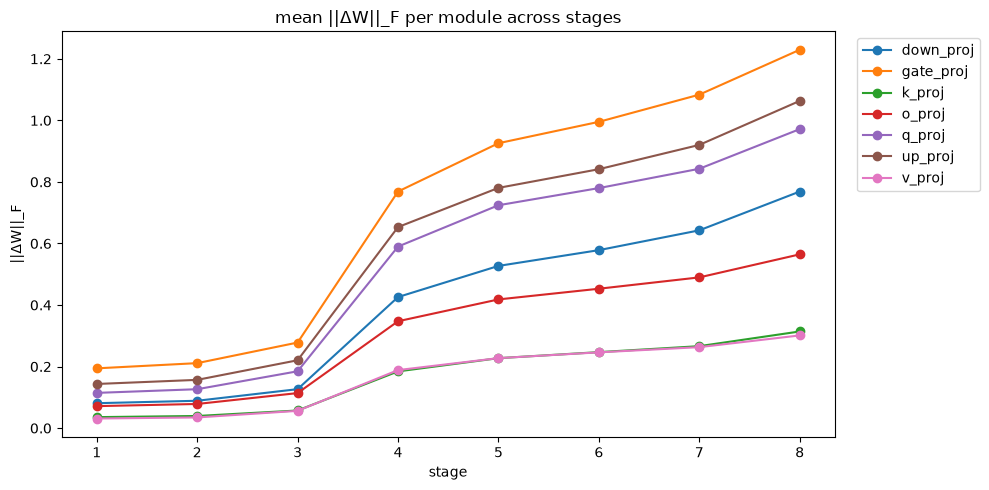

In [4]:
if not (SVD/'scalars.parquet').exists():
    skip('need scalars.parquet')
else:
    scalars = pd.read_parquet(SVD/'scalars.parquet')
    g = scalars.groupby(['stage_idx', 'module'])['fro'].mean().unstack()
    g.plot(marker='o', figsize=(10, 5), title='mean ||ΔW||_F per module across stages')
    plt.xlabel('stage'); plt.ylabel('||ΔW||_F')
    plt.legend(bbox_to_anchor=(1.02, 1)); plt.tight_layout(); plt.show()

### §3.1 Stable rank vs. configured r

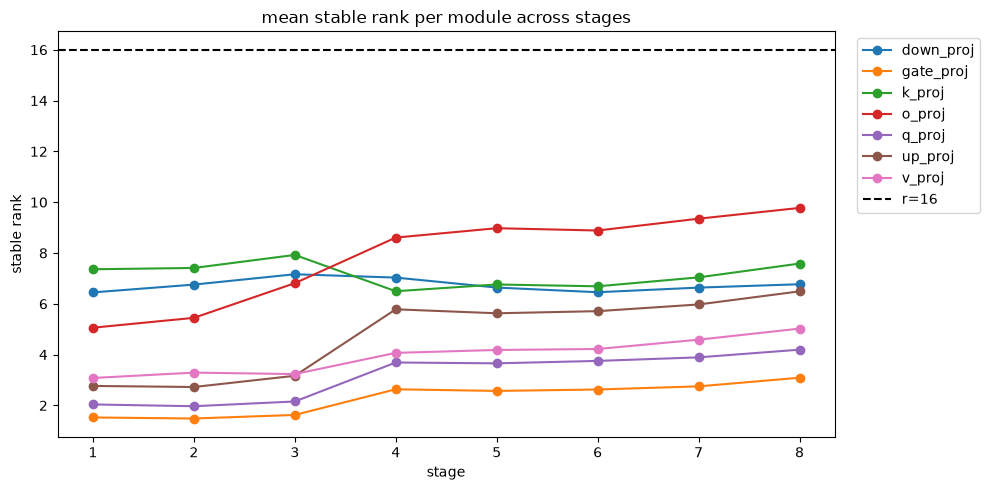

In [5]:
if not (SVD/'scalars.parquet').exists():
    skip('need scalars.parquet')
else:
    scalars = pd.read_parquet(SVD/'scalars.parquet')
    g = scalars.groupby(['stage_idx', 'module'])['stable_rank'].mean().unstack()
    ax = g.plot(marker='o', figsize=(10, 5), title='mean stable rank per module across stages')
    # ax.axhline(scalars.r.iloc[0], color='k', ls='--', label=f'configured r={scalars.r.iloc[0]}')
    ax.axhline(16, color='k', ls='--', label=f'r=16')
    ax.set_xlabel('stage'); ax.set_ylabel('stable rank')
    ax.legend(bbox_to_anchor=(1.02, 1)); plt.tight_layout(); plt.show()

### §3.4 Dead-rank count per module across stages

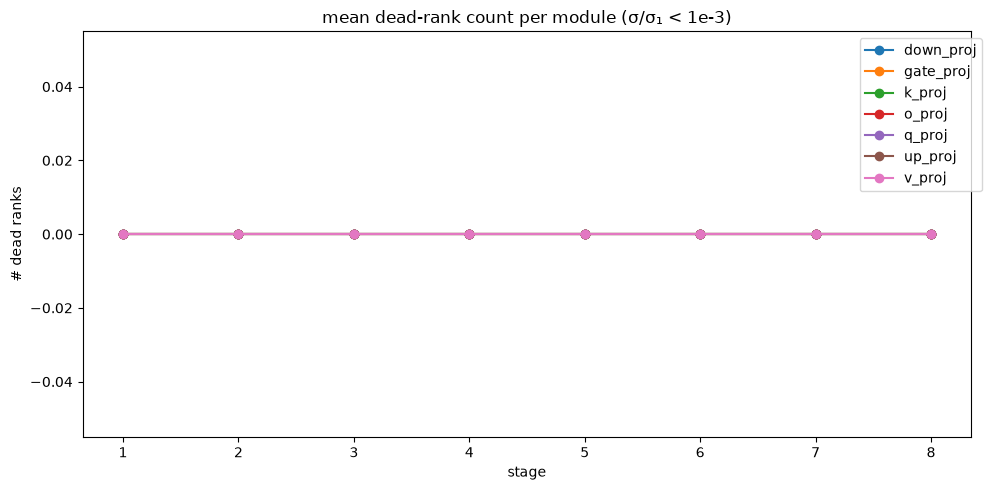

In [6]:
if not (SVD/'scalars.parquet').exists():
    skip('need scalars.parquet')
else:
    scalars = pd.read_parquet(SVD/'scalars.parquet')
    g = scalars.groupby(['stage_idx', 'module'])['dead_rank'].mean().unstack()
    g.plot(marker='o', figsize=(10, 5), title='mean dead-rank count per module (σ/σ₁ < 1e-3)')
    plt.xlabel('stage'); plt.ylabel('# dead ranks')
    plt.legend(bbox_to_anchor=(1.02, 1)); plt.tight_layout(); plt.show()

### §3.3 Subspace drift — mean U overlap vs. previous stage

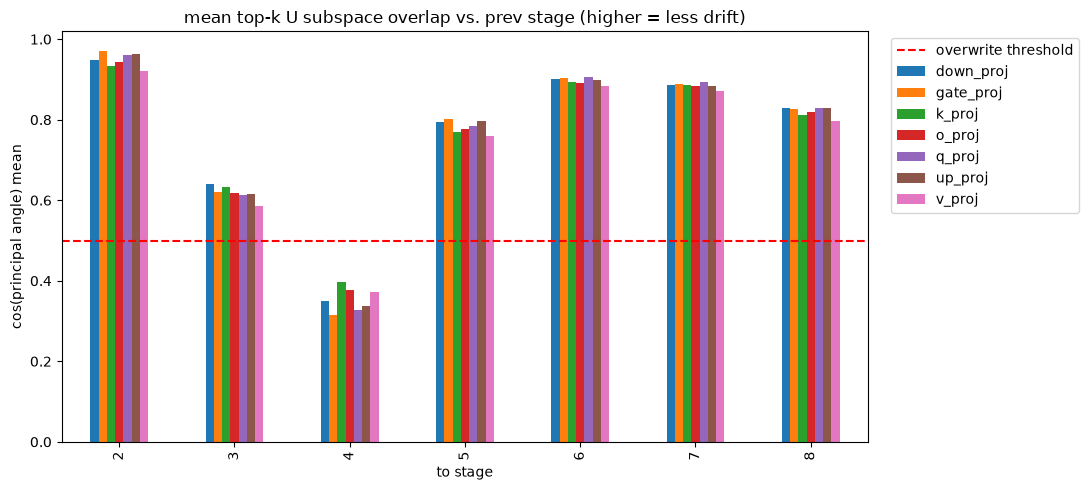

In [7]:
if not (SVD/'drift.parquet').exists():
    skip('need drift.parquet')
else:
    drift = pd.read_parquet(SVD/'drift.parquet')
    pivot = drift.groupby(['to_stage', 'module'])['U_overlap_mean'].mean().unstack()
    ax = pivot.plot(kind='bar', figsize=(11, 5), title='mean top-k U subspace overlap vs. prev stage (higher = less drift)')
    ax.axhline(0.5, color='r', ls='--', label='overwrite threshold')
    ax.set_xlabel('to stage'); ax.set_ylabel('cos(principal angle) mean')
    plt.legend(bbox_to_anchor=(1.02, 1)); plt.tight_layout(); plt.show()

### §3.3 Drift heatmap — U overlap by layer × module (last transition)

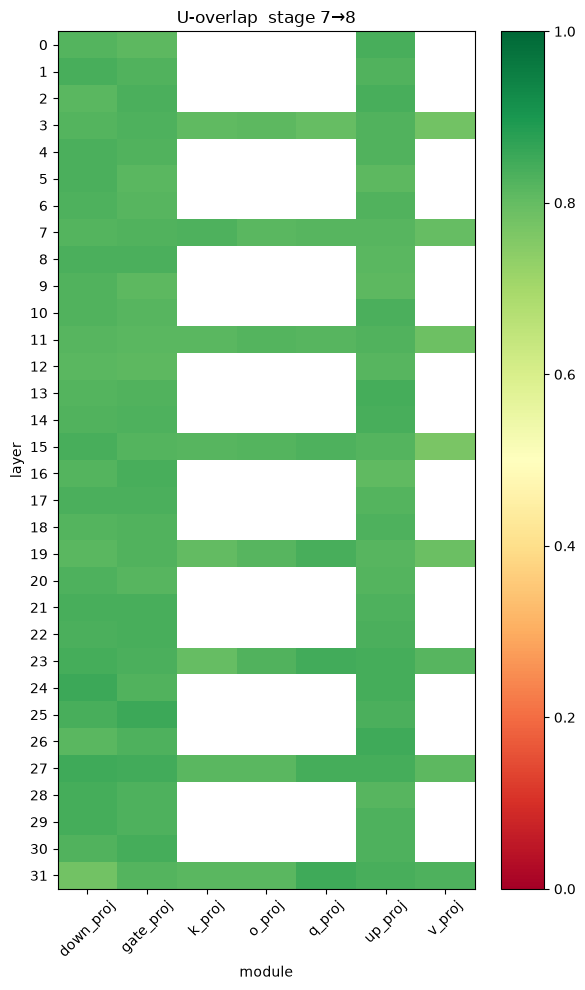

In [8]:
if not (SVD/'drift.parquet').exists():
    skip('need drift.parquet')
else:
    drift = pd.read_parquet(SVD/'drift.parquet')
    last_to = drift.to_stage.max()
    # last_to = 
    d = drift[drift.to_stage == last_to]
    h = d.pivot(index='layer', columns='module', values='U_overlap_mean')
    fig, ax = plt.subplots(figsize=(6, 10))
    im = ax.imshow(h.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(len(h.columns))); ax.set_xticklabels(h.columns, rotation=45)
    ax.set_yticks(range(len(h.index))); ax.set_yticklabels(h.index)
    ax.set(title=f'U-overlap  stage {last_to - 1}→{last_to}', xlabel='module', ylabel='layer')
    plt.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()

### §3.2 A vs B Frobenius asymmetry

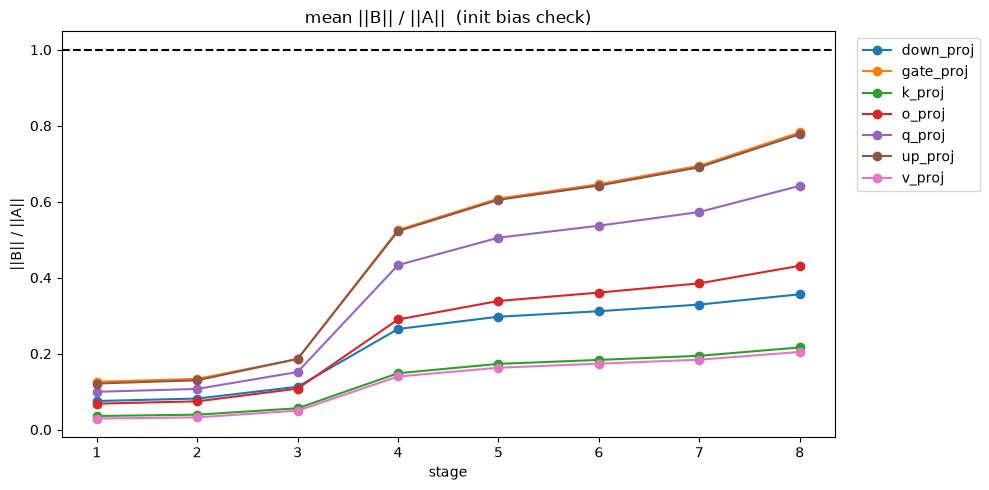

In [9]:
if not (SVD/'scalars.parquet').exists():
    skip('need scalars.parquet')
else:
    scalars = pd.read_parquet(SVD/'scalars.parquet')
    scalars['B_over_A'] = scalars['B_fro'] / scalars['A_fro'].clip(lower=1e-8)
    g = scalars.groupby(['stage_idx', 'module'])['B_over_A'].mean().unstack()
    g.plot(marker='o', figsize=(10, 5), title='mean ||B|| / ||A||  (init bias check)')
    plt.axhline(1.0, color='k', ls='--')
    plt.xlabel('stage'); plt.ylabel('||B|| / ||A||')
    plt.legend(bbox_to_anchor=(1.02, 1)); plt.tight_layout(); plt.show()

## §0 TensorBoard: training loss + grad_norm curves

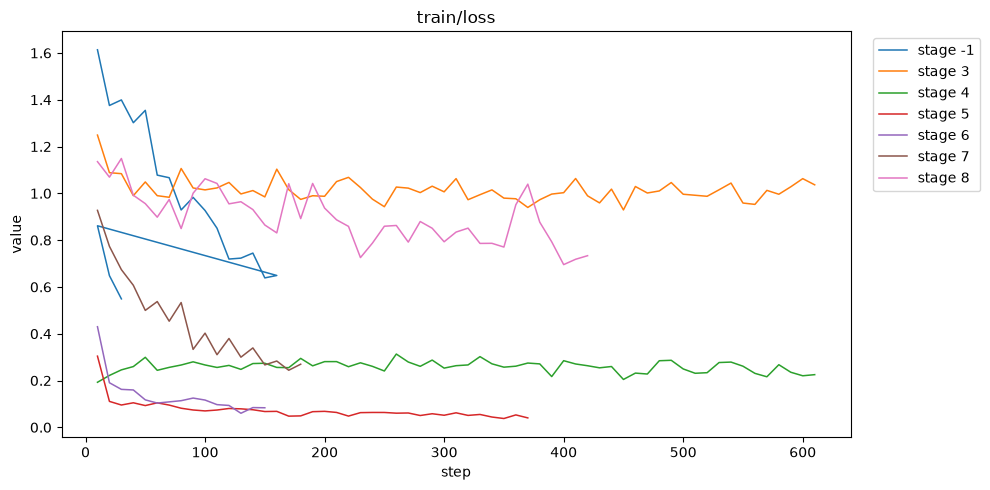

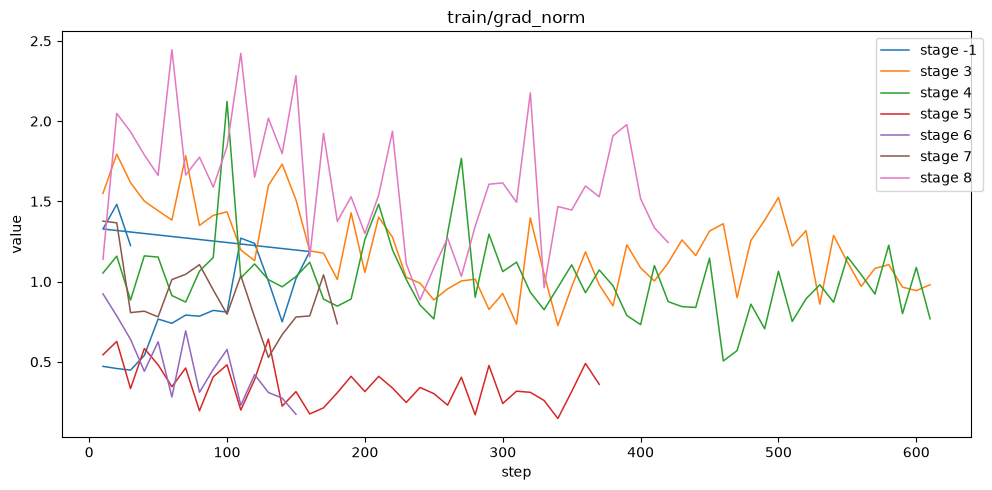

In [10]:
if not (TB/'tb_scalars.parquet').exists():
    skip('run 00_tb_dump.py first')
else:
    tb = pd.read_parquet(TB/'tb_scalars.parquet')
    for tag in ['train/loss', 'train/grad_norm']:
        sub = tb[tb.tag == tag]
        if sub.empty:
            continue
        fig, ax = plt.subplots(figsize=(10, 5))
        for sidx, g in sub.groupby('stage_idx'):
            ax.plot(g.step, g.value, label=f'stage {sidx}', lw=1.1)
        ax.set(title=tag, xlabel='step', ylabel='value')
        ax.legend(bbox_to_anchor=(1.02, 1))
        plt.tight_layout(); plt.show()

## §1 Cross-stage × cross-slice eval loss

In [11]:
if not (LOSS/'loss_matrix.parquet').exists():
    skip('run 01_loss_matrix.py first')
else:
    loss = pd.read_parquet(LOSS/'loss_matrix.parquet')
    h = loss.pivot(index='stage_idx', columns='slice', values='mean_loss')
    fig, ax = plt.subplots(figsize=(9, 5))
    im = ax.imshow(h.values, aspect='auto', cmap='magma_r')
    for i in range(h.shape[0]):
        for j in range(h.shape[1]):
            ax.text(j, i, f'{h.values[i, j]:.2f}', ha='center', va='center', color='w', fontsize=8)
    ax.set_xticks(range(len(h.columns))); ax.set_xticklabels(h.columns, rotation=45)
    ax.set_yticks(range(len(h.index))); ax.set_yticklabels(h.index)
    ax.set(title='mean CE — stage × slice', xlabel='slice', ylabel='stage')
    plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

skip: run 01_loss_matrix.py first


## §2 Grad-norm heatmap + cross-slice cosine

In [12]:
if not (GRAD/'global.parquet').exists():
    skip('run 02_gradnorm_matrix.py first')
else:
    gnorm = pd.read_parquet(GRAD/'global.parquet')
    h = gnorm.pivot(index='stage_idx', columns='slice', values='global_grad_norm')
    h.plot(kind='bar', figsize=(11, 5), title='global grad norm — stage × slice')
    plt.tight_layout(); plt.show()
    if (GRAD/'cross_slice_cosine.parquet').exists():
        cos = pd.read_parquet(GRAD/'cross_slice_cosine.parquet')
        print(cos.pivot(index='stage_idx', columns='pair', values='cosine').round(3))

skip: run 02_gradnorm_matrix.py first
